## КТ2 Тема: Полиномиальная регрессия

В рамках выполнения практической работы №2 выполняется исследование набора данных объема продаж мороженого, построение и проверка рабочей гипотезы.

Цель работы: выполнить построение полиномиальной модели зависимости 
продажи мороженого от температуры.

Задачи:
<ol>
    <li>Прочитать и исследовать данных продаж</li>
    <li>На основе визуализации данных сделать предположение
    (гипотезу) закономерности влияния температуры воздуха
    на объем продаж мороженого</li>
    <li>Построить модель и оценить ее</li>
    <li>Выбрать конкурирующую модель и также оценить ее</li>
    <li>Сделать выводы о прогнозировании объема продаж мороженого
    в зависимости от температуры воздуха</li>
</ol>

<img src='CRISP_DM.jpg'>

In [2]:
import pandas as pd

df = pd.read_csv('Ice_cream selling data.csv') #df - DataFrame

df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [3]:
print(df)

X = list(df['Temperature (°C)']) #преобразуем в тип список
y = list(df['Ice Cream Sales (units)'])


    Temperature (°C)  Ice Cream Sales (units)
0          -4.662263                41.842986
1          -4.316559                34.661120
2          -4.213985                39.383001
3          -3.949661                37.539845
4          -3.578554                32.284531
5          -3.455712                30.001138
6          -3.108440                22.635401
7          -3.081303                25.365022
8          -2.672461                19.226970
9          -2.652287                20.279679
10         -2.651498                13.275828
11         -2.288264                18.123991
12         -2.111870                11.218294
13         -1.818938                10.012868
14         -1.660348                12.615181
15         -1.326379                10.957731
16         -1.173123                 6.689123
17         -0.773330                 9.392969
18         -0.673753                 5.210163
19         -0.149635                 4.673643
20         -0.036156              

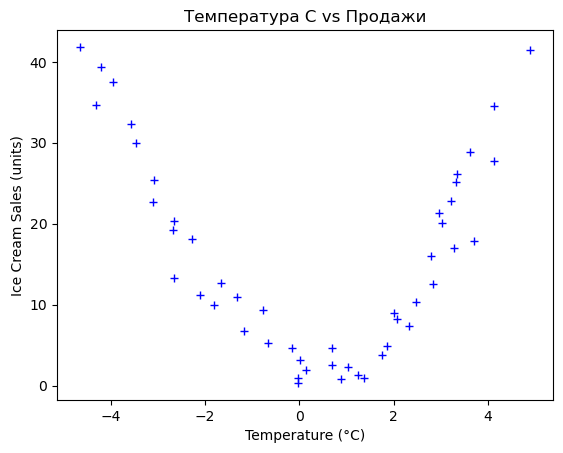

In [4]:
from matplotlib import pyplot as plt

#визуализируем генеральную совокупность

figure = plt.figure()
plt.plot(X,y,'b+')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Температура С vs Продажи')
plt.show()

## Разработка модели

Наблюдаемое облако точек в сопоставлении температуры воздуха и продаж морожено позволяет предположить наличие степенной зависимости объема продаж от температуры. В самом общем случае, эта зависимость может быть выражена в виде уравнения полиномиальной регрессии.

В практической работе 1 данные разделялись по диапазону значений. В этой практической работе такой подход не применим, так как необходимо рандомизировать значения выборки для обучения и тестовой. В качестве инструмента выбираем функцию train_test_split модуля modeling библиотеки scikit-learn

Всего записей в наборе для обучения 39
Всего записей в наборе для тестирования 10


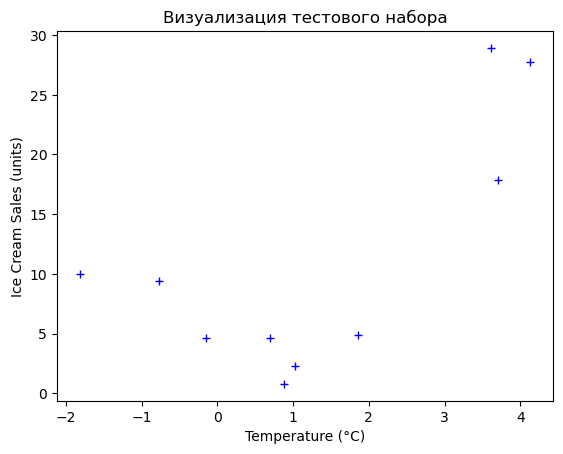

In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42, shuffle=True)

print('Всего записей в наборе для обучения',len(X_train))
print('Всего записей в наборе для тестирования',len(X_test))

figure = plt.figure()
plt.plot(X_test,y_test,'b+')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Визуализация тестового набора')
plt.show()


In [6]:
#Задача. Дан список произвольных чисел.
#Создать список квадратов этих чисел

numbers = [1, 20, 3.14, 10, 0.34, 81]


# squares = []

# for i in numbers:
#     squares.append(i**2)


squares = [i**2 for i in numbers]

print(squares)    
    

[1, 400, 9.8596, 100, 0.11560000000000002, 6561]


Моделирование полинома
X_test [-1.8189376094349368, 3.704057438377216, 4.133533788303586, 3.61077847766804, -0.773330043103446, 1.0241808138155706, 0.8749050291584157, 0.6935988725293257, 1.850551925836895, -0.1496348665335983]
y_test [10.012867848328883, 17.84395651991352, 27.69838334813044, 28.912187929191944, 9.392968661109096, 2.313806358173546, 0.7899736505077737, 4.625689457527259, 4.857987801146915, 4.673642540546473]
type(X_test) <class 'list'>
type(y_test) <class 'list'>
[ 1.87145125 -0.70641926  2.76830583]
X -1.8189376094349368
f_x 10.244998524618618
alt f_x 10.244998524618618


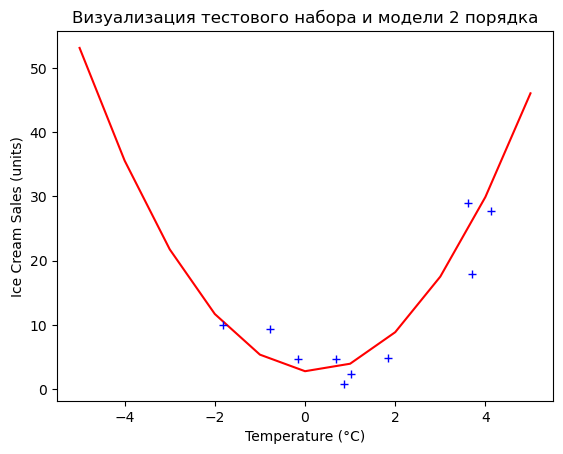

In [7]:
import numpy as np

print('Моделирование полинома')

print('X_test',X_test)
print('y_test',y_test)

print('type(X_test)',type(X_test))
print('type(y_test)',type(y_test))

#help(np.polyfit)

coeff = np.polyfit(X_train, y_train, deg=2)

def model_norder(coeff,x):
    summands = [c*x**p for c,p in zip(coeff,list(range(0,len(coeff)))[::-1])]
    return sum(summands)

print(coeff)

f_x = lambda x: coeff[0]*x**2 + coeff[1]*x + coeff[2]

print('X',X_test[0])
print('f_x',f_x(X_test[0]))
print('alt f_x',model_norder(coeff,X_test[0]))


#y_model2 - значение на выходе модели 2 порядка
#y_model2 = [f_x(el) for el in X_test]
#print('y_model2',y_model2)

#Строим кривую для всего диапазона температур воздуха (вход модели)

x_model2 = list(range(-5,6))
y_model2 = [f_x(el) for el in x_model2]

figure = plt.figure()
plt.plot(x_model2,y_model2,'r-')
plt.plot(X_test,y_test,'b+')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Визуализация тестового набора и модели 2 порядка')
plt.show()


In [12]:
print('Вычисление метрик качества обучения для полинома 2 порядка')

#X_test y_test

coeff = np.polyfit(X_train, y_train, deg=2)

print('coeff=',coeff)

def model_norder(coeff,x):
    summands = [c*x**p for c,p in zip(coeff,list(range(0,len(coeff)))[::-1])]
    return sum(summands)

#создаю набор y для тестовых значений X

ymodel = [model_norder(coeff,xi) for xi in X_test]

print('ymodel',ymodel)

print('y_test',y_test)


delta_m = [((ym-yt)**2)**0.5 for ym,yt in zip(ymodel,y_test)]
#относительная ошибка
relative_delta_m = [(((ym-yt)**2)**0.5)/yt for ym,yt in zip(ymodel,y_test)]

print('delta_m',delta_m)

#mean absolute error
MAE = sum(delta_m)/len(delta_m)
print('MAE',MAE)

RelMSE = 100*sum(relative_delta_m)/len(relative_delta_m)

print('RelMSE',RelMSE,'%')

delta_m_rel = [100*(((ym-yt)**2)**0.5)/yt for ym,yt in zip(ymodel,y_test)]
print('delta_m_rel',delta_m_rel)



Вычисление метрик качества обучения для полинома 2 порядка
coeff= [ 1.87145125 -0.70641926  2.76830583]
ymodel [10.244998524618618, 25.828077140966794, 31.824104104081503, 24.617042032254005, 4.433802564054448, 4.007856716236445, 3.5827749143291885, 3.1786508652330774, 7.86990452048655, 2.915913684753996]
y_test [10.012867848328883, 17.84395651991352, 27.69838334813044, 28.912187929191944, 9.392968661109096, 2.313806358173546, 0.7899736505077737, 4.625689457527259, 4.857987801146915, 4.673642540546473]
delta_m [0.23213067628973505, 7.984120621053275, 4.125720755951061, 4.295145896937939, 4.9591660970546485, 1.6940503580628987, 2.792801263821415, 1.4470385922941817, 3.0119167193396352, 1.7577288557924775]
MAE 3.2299819836597266
RelMSE 68.72471496082022 %
delta_m_rel [2.3183235792778087, 44.7441160941137, 14.895168082903782, 14.85583141427091, 52.79657875989425, 73.2148717665438, 353.530938915023, 31.282657549340136, 61.99926477025233, 37.6093986765824]


In [13]:
#A/B тестирование
print('Вычисление метрик качества обучения для полинома 3 порядка')

#X_test y_test

coeff = np.polyfit(X_train, y_train, deg=3)

print('coeff=',coeff)

def model_norder(coeff,x):
    summands = [c*x**p for c,p in zip(coeff,list(range(0,len(coeff)))[::-1])]
    return sum(summands)

#создаю набор y для тестовых значений X

ymodel = [model_norder(coeff,xi) for xi in X_test]

print('ymodel',ymodel)

print('y_test',y_test)


delta_m = [((ym-yt)**2)**0.5 for ym,yt in zip(ymodel,y_test)]
#относительная ошибка
relative_delta_m = [(((ym-yt)**2)**0.5)/yt for ym,yt in zip(ymodel,y_test)]

print('delta_m',delta_m)

#mean absolute error
MAE = sum(delta_m)/len(delta_m)
print('MAE',MAE)

RelMSE = 100*sum(relative_delta_m)/len(relative_delta_m)

print('RelMSE',RelMSE,'%')

delta_m_rel = [100*(((ym-yt)**2)**0.5)/yt for ym,yt in zip(ymodel,y_test)]
print('delta_m_rel',delta_m_rel)



Вычисление метрик качества обучения для полинома 3 порядка
coeff= [ 0.05451597  1.87501919 -1.39956426  2.84053099]
ymodel [11.261737824774386, 26.152297439055797, 32.94239669036326, 24.79940324860863, 5.018978697176625, 3.4324857304327674, 3.0878046858384867, 2.790018571753788, 7.017131119618435, 3.091754736948936]
y_test [10.012867848328883, 17.84395651991352, 27.69838334813044, 28.912187929191944, 9.392968661109096, 2.313806358173546, 0.7899736505077737, 4.625689457527259, 4.857987801146915, 4.673642540546473]
delta_m [1.2488699764455031, 8.308340919142278, 5.244013342232819, 4.112784680583314, 4.3739899639324715, 1.1186793722592214, 2.297831035330713, 1.835670885773471, 2.1591433184715205, 1.5818878035975374]
MAE 3.2281211297768855
RelMSE 59.59569195428016 %
delta_m_rel [12.472650147419412, 46.561091481423, 18.9325610679974, 14.225089746427436, 46.56664066220788, 48.348011851012274, 290.8743897791692, 39.68426550524989, 44.44521902590558, 33.84700027598971]
